<a href="https://colab.research.google.com/github/Nazarsiska735/Artificial-/blob/main/assignment3_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3

1. Полносвязная нейронная сеть
2. Нормализация по мини-батчам (Batch Normalization)
3. Dropout
4. Сверточные нейронные сети (CNN)

## 0. Установка и клонирование репозитория

In [1]:
!git clone https://github.com/JustHawker/AIT_Course_SamU_2026.git 2>/dev/null || echo "Already cloned"
%cd /content/AIT_Course_SamU_2026/lab_3
import sys
sys.path.insert(0, '/content/AIT_Course_SamU_2026/lab_3')
print("Готово ✓")


/content/AIT_Course_SamU_2026/lab_3
Готово ✓


## Реализация `scripts/layers.py`

In [2]:
%%writefile scripts/layers.py
import numpy as np

def affine_forward(x, w, b):
    out = x.reshape(x.shape[0], -1).dot(w) + b
    cache = (x, w, b)
    return out, cache

def affine_backward(dout, cache):
    x, w, b = cache
    x_flat = x.reshape(x.shape[0], -1)
    dx = dout.dot(w.T).reshape(x.shape)
    dw = x_flat.T.dot(dout)
    db = dout.sum(axis=0)
    return dx, dw, db

def relu_forward(x):
    out = np.maximum(0, x)
    cache = x
    return out, cache

def relu_backward(dout, cache):
    x = cache
    dx = dout * (x > 0)
    return dx

def batchnorm_forward(x, gamma, beta, bn_param):
    mode = bn_param['mode']
    eps = bn_param.get('eps', 1e-5)
    momentum = bn_param.get('momentum', 0.9)
    N, D = x.shape
    running_mean = bn_param.get('running_mean', np.zeros(D, dtype=x.dtype))
    running_var  = bn_param.get('running_var',  np.ones(D,  dtype=x.dtype))

    if mode == 'train':
        mu    = x.mean(axis=0)
        var   = x.var(axis=0)
        x_hat = (x - mu) / np.sqrt(var + eps)
        out   = gamma * x_hat + beta
        bn_param['running_mean'] = momentum * running_mean + (1 - momentum) * mu
        bn_param['running_var']  = momentum * running_var  + (1 - momentum) * var
        cache = (x, x_hat, mu, var, gamma, beta, eps)
    elif mode == 'test':
        x_hat = (x - running_mean) / np.sqrt(running_var + eps)
        out   = gamma * x_hat + beta
        cache = None
    else:
        raise ValueError('Invalid forward batchnorm mode "%s"' % mode)
    return out, cache

def batchnorm_backward(dout, cache):
    x, x_hat, mu, var, gamma, beta, eps = cache
    N, D = dout.shape
    dgamma = (dout * x_hat).sum(axis=0)
    dbeta  = dout.sum(axis=0)
    dx_hat = dout * gamma
    dvar   = (dx_hat * (x - mu) * (-0.5) * (var + eps)**(-1.5)).sum(axis=0)
    dmu    = (dx_hat * (-1.0 / np.sqrt(var + eps))).sum(axis=0) + dvar * (-2.0 * (x - mu)).mean(axis=0)
    dx     = dx_hat / np.sqrt(var + eps) + dvar * 2.0 * (x - mu) / N + dmu / N
    return dx, dgamma, dbeta

def layernorm_forward(x, gamma, beta, ln_param):
    eps = ln_param.get('eps', 1e-5)
    mu    = x.mean(axis=1, keepdims=True)
    var   = x.var(axis=1,  keepdims=True)
    x_hat = (x - mu) / np.sqrt(var + eps)
    out   = gamma * x_hat + beta
    cache = (x, x_hat, mu, var, gamma, beta, eps)
    return out, cache

def layernorm_backward(dout, cache):
    x, x_hat, mu, var, gamma, beta, eps = cache
    N, D = dout.shape
    dgamma = (dout * x_hat).sum(axis=0)
    dbeta  = dout.sum(axis=0)
    dx_hat = dout * gamma
    dvar   = (dx_hat * (x - mu) * (-0.5) * (var + eps)**(-1.5)).sum(axis=1, keepdims=True)
    dmu    = (dx_hat / (-np.sqrt(var + eps))).sum(axis=1, keepdims=True) + dvar * (-2.0*(x-mu)).mean(axis=1, keepdims=True)
    dx     = dx_hat / np.sqrt(var + eps) + dvar * 2.0*(x-mu)/D + dmu/D
    return dx, dgamma, dbeta

def dropout_forward(x, dropout_param):
    p    = dropout_param['p']
    mode = dropout_param['mode']
    if 'seed' in dropout_param:
        np.random.seed(dropout_param['seed'])
    if mode == 'train':
        mask = (np.random.rand(*x.shape) > p) / (1.0 - p)
        out  = x * mask
    else:
        out  = x
        mask = None
    cache = (dropout_param, mask)
    return out, cache

def dropout_backward(dout, cache):
    dropout_param, mask = cache
    mode = dropout_param['mode']
    if mode == 'train':
        dx = dout * mask
    else:
        dx = dout
    return dx

def conv_forward_naive(x, w, b, conv_param):
    N, C, H, W_   = x.shape
    F, _, HH, WW  = w.shape
    stride = conv_param['stride']
    pad    = conv_param['pad']
    H_out  = 1 + (H + 2*pad - HH) // stride
    W_out  = 1 + (W_ + 2*pad - WW) // stride
    x_pad  = np.pad(x, ((0,),(0,),(pad,),(pad,)), mode='constant')
    out    = np.zeros((N, F, H_out, W_out))
    for n in range(N):
        for f in range(F):
            for i in range(H_out):
                for j in range(W_out):
                    h0, w0 = i*stride, j*stride
                    out[n,f,i,j] = np.sum(x_pad[n,:,h0:h0+HH,w0:w0+WW] * w[f]) + b[f]
    cache = (x, w, b, conv_param)
    return out, cache

def conv_backward_naive(dout, cache):
    x, w, b, conv_param = cache
    N, C, H, W_   = x.shape
    F, _, HH, WW  = w.shape
    stride = conv_param['stride']
    pad    = conv_param['pad']
    H_out, W_out  = dout.shape[2], dout.shape[3]
    x_pad  = np.pad(x, ((0,),(0,),(pad,),(pad,)), mode='constant')
    dx_pad = np.zeros_like(x_pad)
    dw     = np.zeros_like(w)
    db     = np.zeros_like(b)
    for n in range(N):
        for f in range(F):
            db[f] += dout[n,f].sum()
            for i in range(H_out):
                for j in range(W_out):
                    h0, w0 = i*stride, j*stride
                    dw[f]          += x_pad[n,:,h0:h0+HH,w0:w0+WW] * dout[n,f,i,j]
                    dx_pad[n,:,h0:h0+HH,w0:w0+WW] += w[f] * dout[n,f,i,j]
    dx = dx_pad[:,:,pad:-pad,pad:-pad] if pad > 0 else dx_pad
    return dx, dw, db

def max_pool_forward_naive(x, pool_param):
    N, C, H, W_ = x.shape
    ph = pool_param['pool_height']
    pw = pool_param['pool_width']
    s  = pool_param['stride']
    H_out = (H - ph) // s + 1
    W_out = (W_ - pw) // s + 1
    out   = np.zeros((N, C, H_out, W_out))
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    out[n,c,i,j] = x[n,c,i*s:i*s+ph, j*s:j*s+pw].max()
    cache = (x, pool_param)
    return out, cache

def max_pool_backward_naive(dout, cache):
    x, pool_param = cache
    N, C, H, W_ = x.shape
    ph = pool_param['pool_height']
    pw = pool_param['pool_width']
    s  = pool_param['stride']
    H_out, W_out = dout.shape[2], dout.shape[3]
    dx = np.zeros_like(x)
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    patch = x[n,c,i*s:i*s+ph, j*s:j*s+pw]
                    mask  = (patch == patch.max())
                    dx[n,c,i*s:i*s+ph, j*s:j*s+pw] += mask * dout[n,c,i,j]
    return dx

def spatial_batchnorm_forward(x, gamma, beta, bn_param):
    N, C, H, W = x.shape
    x_reshaped = x.transpose(0,2,3,1).reshape(-1, C)
    out_flat, cache = batchnorm_forward(x_reshaped, gamma, beta, bn_param)
    out = out_flat.reshape(N, H, W, C).transpose(0,3,1,2)
    return out, cache

def spatial_batchnorm_backward(dout, cache):
    N, C, H, W = dout.shape
    dout_flat = dout.transpose(0,2,3,1).reshape(-1, C)
    dx_flat, dgamma, dbeta = batchnorm_backward(dout_flat, cache)
    dx = dx_flat.reshape(N, H, W, C).transpose(0,3,1,2)
    return dx, dgamma, dbeta

def svm_loss(x, y):
    N = x.shape[0]
    correct = x[np.arange(N), y]
    margins = np.maximum(0, x - correct[:,None] + 1.0)
    margins[np.arange(N), y] = 0
    loss = margins.sum() / N
    dx   = (margins > 0).astype(float)
    dx[np.arange(N), y] -= dx.sum(axis=1)
    dx /= N
    return loss, dx

def softmax_loss(x, y):
    N = x.shape[0]
    x_shifted = x - x.max(axis=1, keepdims=True)
    probs = np.exp(x_shifted) / np.exp(x_shifted).sum(axis=1, keepdims=True)
    loss  = -np.log(probs[np.arange(N), y] + 1e-15).mean()
    dx    = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N
    return loss, dx


Overwriting scripts/layers.py


## Реализация `scripts/layer_utils.py`

In [3]:
%%writefile scripts/layer_utils.py
from scripts.layers import *

def affine_relu_forward(x, w, b):
    a, fc_cache   = affine_forward(x, w, b)
    out, relu_cache = relu_forward(a)
    cache = (fc_cache, relu_cache)
    return out, cache

def affine_relu_backward(dout, cache):
    fc_cache, relu_cache = cache
    da         = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db

def affine_bn_relu_forward(x, w, b, gamma, beta, bn_param):
    a, fc_cache    = affine_forward(x, w, b)
    bn, bn_cache   = batchnorm_forward(a, gamma, beta, bn_param)
    out, relu_cache = relu_forward(bn)
    cache = (fc_cache, bn_cache, relu_cache)
    return out, cache

def affine_bn_relu_backward(dout, cache):
    fc_cache, bn_cache, relu_cache = cache
    dbn        = relu_backward(dout, relu_cache)
    da, dgamma, dbeta = batchnorm_backward(dbn, bn_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db, dgamma, dbeta

def conv_relu_forward(x, w, b, conv_param):
    a, conv_cache   = conv_forward_naive(x, w, b, conv_param)
    out, relu_cache = relu_forward(a)
    cache = (conv_cache, relu_cache)
    return out, cache

def conv_relu_backward(dout, cache):
    conv_cache, relu_cache = cache
    da         = relu_backward(dout, relu_cache)
    dx, dw, db = conv_backward_naive(da, conv_cache)
    return dx, dw, db

def conv_relu_pool_forward(x, w, b, conv_param, pool_param):
    a, conv_cache   = conv_forward_naive(x, w, b, conv_param)
    s, relu_cache   = relu_forward(a)
    out, pool_cache = max_pool_forward_naive(s, pool_param)
    cache = (conv_cache, relu_cache, pool_cache)
    return out, cache

def conv_relu_pool_backward(dout, cache):
    conv_cache, relu_cache, pool_cache = cache
    ds         = max_pool_backward_naive(dout, pool_cache)
    da         = relu_backward(ds, relu_cache)
    dx, dw, db = conv_backward_naive(da, conv_cache)
    return dx, dw, db


Overwriting scripts/layer_utils.py


## Реализация `scripts/optim.py`

In [4]:
%%writefile scripts/optim.py
import numpy as np

def sgd(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-2)
    w -= config['learning_rate'] * dw
    return w, config

def sgd_momentum(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-2)
    config.setdefault('momentum', 0.9)
    config.setdefault('velocity', np.zeros_like(w))
    v  = config['momentum'] * config['velocity'] - config['learning_rate'] * dw
    config['velocity'] = v
    next_w = w + v
    return next_w, config

def rmsprop(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-2)
    config.setdefault('decay_rate', 0.99)
    config.setdefault('epsilon', 1e-8)
    config.setdefault('cache', np.zeros_like(w))
    config['cache'] = config['decay_rate']*config['cache'] + (1-config['decay_rate'])*(dw**2)
    next_w = w - config['learning_rate'] * dw / (np.sqrt(config['cache']) + config['epsilon'])
    return next_w, config

def adam(w, dw, config=None):
    if config is None: config = {}
    config.setdefault('learning_rate', 1e-3)
    config.setdefault('beta1', 0.9)
    config.setdefault('beta2', 0.999)
    config.setdefault('epsilon', 1e-8)
    config.setdefault('m', np.zeros_like(w))
    config.setdefault('v', np.zeros_like(w))
    config.setdefault('t', 0)
    config['t'] += 1
    config['m'] = config['beta1']*config['m'] + (1-config['beta1'])*dw
    config['v'] = config['beta2']*config['v'] + (1-config['beta2'])*(dw**2)
    m_hat = config['m'] / (1 - config['beta1']**config['t'])
    v_hat = config['v'] / (1 - config['beta2']**config['t'])
    next_w = w - config['learning_rate'] * m_hat / (np.sqrt(v_hat) + config['epsilon'])
    return next_w, config


Overwriting scripts/optim.py


## Реализация `scripts/classifiers/fc_net.py`

In [5]:
%%writefile scripts/classifiers/fc_net.py
import numpy as np
from scripts.layers import *
from scripts.layer_utils import *

class TwoLayerNet:
    def __init__(self, input_dim=3*32*32, hidden_dim=100, num_classes=10,
                 weight_scale=1e-3, reg=0.0):
        self.params = {
            'W1': weight_scale * np.random.randn(input_dim, hidden_dim),
            'b1': np.zeros(hidden_dim),
            'W2': weight_scale * np.random.randn(hidden_dim, num_classes),
            'b2': np.zeros(num_classes),
        }
        self.reg = reg

    def loss(self, X, y=None):
        W1,b1 = self.params['W1'], self.params['b1']
        W2,b2 = self.params['W2'], self.params['b2']

        h, cache1 = affine_relu_forward(X, W1, b1)
        scores, cache2 = affine_forward(h, W2, b2)

        if y is None:
            return scores

        loss, dscores = softmax_loss(scores, y)
        loss += 0.5*self.reg*(np.sum(W1**2)+np.sum(W2**2))

        dh, dW2, db2 = affine_backward(dscores, cache2)
        dX, dW1, db1 = affine_relu_backward(dh, cache1)
        dW2 += self.reg * W2
        dW1 += self.reg * W1

        grads = {'W1':dW1,'b1':db1,'W2':dW2,'b2':db2}
        return loss, grads


class FullyConnectedNet:
    def __init__(self, hidden_dims, input_dim=3*32*32, num_classes=10,
                 dropout=1, normalization=None, reg=0.0,
                 weight_scale=1e-2, dtype=np.float32, seed=None):
        self.normalization = normalization
        self.use_dropout   = dropout != 1
        self.reg           = reg
        self.num_layers    = 1 + len(hidden_dims)
        self.dtype         = dtype
        self.params        = {}

        dims = [input_dim] + list(hidden_dims) + [num_classes]
        for i in range(self.num_layers):
            self.params[f'W{i+1}'] = weight_scale * np.random.randn(dims[i], dims[i+1])
            self.params[f'b{i+1}'] = np.zeros(dims[i+1])
            if normalization in ('batchnorm','layernorm') and i < self.num_layers-1:
                self.params[f'gamma{i+1}'] = np.ones(dims[i+1])
                self.params[f'beta{i+1}']  = np.zeros(dims[i+1])

        self.dropout_param = {}
        if self.use_dropout:
            self.dropout_param = {'mode':'train','p':dropout}
            if seed is not None:
                self.dropout_param['seed'] = seed

        self.bn_params = []
        if normalization == 'batchnorm':
            self.bn_params = [{'mode':'train'} for _ in range(self.num_layers-1)]
        if normalization == 'layernorm':
            self.bn_params = [{} for _ in range(self.num_layers-1)]

        for k,v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        X = X.astype(self.dtype)
        mode = 'test' if y is None else 'train'
        if self.use_dropout:
            self.dropout_param['mode'] = mode
        if self.normalization == 'batchnorm':
            for bp in self.bn_params:
                bp['mode'] = mode

        caches = []
        out = X
        for i in range(self.num_layers - 1):
            W = self.params[f'W{i+1}']
            b = self.params[f'b{i+1}']
            if self.normalization == 'batchnorm':
                gamma = self.params[f'gamma{i+1}']
                beta  = self.params[f'beta{i+1}']
                out, cache = affine_bn_relu_forward(out, W, b, gamma, beta, self.bn_params[i])
            elif self.normalization == 'layernorm':
                gamma = self.params[f'gamma{i+1}']
                beta  = self.params[f'beta{i+1}']
                a, fc_c = affine_forward(out, W, b)
                a, ln_c = layernorm_forward(a, gamma, beta, self.bn_params[i])
                out, rl_c = relu_forward(a)
                cache = (fc_c, ln_c, rl_c, 'ln')
            else:
                out, cache = affine_relu_forward(out, W, b)
            caches.append(cache)
            if self.use_dropout:
                out, dc = dropout_forward(out, self.dropout_param)
                caches.append(('dropout', dc))

        W = self.params[f'W{self.num_layers}']
        b = self.params[f'b{self.num_layers}']
        scores, cache = affine_forward(out, W, b)
        caches.append(cache)

        if y is None:
            return scores

        loss, dscores = softmax_loss(scores, y)
        for i in range(1, self.num_layers+1):
            loss += 0.5 * self.reg * np.sum(self.params[f'W{i}']**2)

        grads = {}
        dx, dW, db = affine_backward(dscores, caches.pop())
        dW += self.reg * self.params[f'W{self.num_layers}']
        grads[f'W{self.num_layers}'] = dW
        grads[f'b{self.num_layers}'] = db

        for i in range(self.num_layers-2, -1, -1):
            if self.use_dropout:
                _, dc = caches.pop()
                dx = dropout_backward(dx, dc)
            cache = caches.pop()
            if self.normalization == 'batchnorm':
                dx, dW, db, dgamma, dbeta = affine_bn_relu_backward(dx, cache)
                grads[f'gamma{i+1}'] = dgamma
                grads[f'beta{i+1}']  = dbeta
            elif self.normalization == 'layernorm':
                fc_c, ln_c, rl_c, _ = cache
                dx = relu_backward(dx, rl_c)
                dx, dgamma, dbeta = layernorm_backward(dx, ln_c)
                dx, dW, db = affine_backward(dx, fc_c)
                grads[f'gamma{i+1}'] = dgamma
                grads[f'beta{i+1}']  = dbeta
            else:
                dx, dW, db = affine_relu_backward(dx, cache)
            dW += self.reg * self.params[f'W{i+1}']
            grads[f'W{i+1}'] = dW
            grads[f'b{i+1}'] = db

        return loss, grads


Overwriting scripts/classifiers/fc_net.py


## Реализация `scripts/classifiers/cnn.py`

In [6]:
%%writefile scripts/classifiers/cnn.py
import numpy as np
from scripts.layers import *
from scripts.layer_utils import *

class ThreeLayerConvNet:
    """
    Архитектура:
    conv - relu - 2x2 max pool - affine - relu - affine - softmax
    """
    def __init__(self, input_dim=(3,32,32), num_filters=32, filter_size=7,
                 hidden_dim=100, num_classes=10, weight_scale=1e-3, reg=0.0,
                 dtype=np.float32):
        self.params = {}
        self.reg    = reg
        self.dtype  = dtype

        C, H, W = input_dim
        # Conv layer
        self.params['W1'] = weight_scale * np.random.randn(num_filters, C, filter_size, filter_size)
        self.params['b1'] = np.zeros(num_filters)
        # After conv+pool: size = num_filters * H/2 * W/2
        pool_h = H // 2
        pool_w = W // 2
        self.params['W2'] = weight_scale * np.random.randn(num_filters * pool_h * pool_w, hidden_dim)
        self.params['b2'] = np.zeros(hidden_dim)
        self.params['W3'] = weight_scale * np.random.randn(hidden_dim, num_classes)
        self.params['b3'] = np.zeros(num_classes)

        for k,v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        X = X.astype(self.dtype)
        W1,b1 = self.params['W1'], self.params['b1']
        W2,b2 = self.params['W2'], self.params['b2']
        W3,b3 = self.params['W3'], self.params['b3']

        filter_size = W1.shape[2]
        conv_param  = {'stride': 1, 'pad': (filter_size-1)//2}
        pool_param  = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

        out1, cache1 = conv_relu_pool_forward(X, W1, b1, conv_param, pool_param)
        out2, cache2 = affine_relu_forward(out1, W2, b2)
        scores, cache3 = affine_forward(out2, W3, b3)

        if y is None:
            return scores

        loss, dscores = softmax_loss(scores, y)
        loss += 0.5*self.reg*(np.sum(W1**2)+np.sum(W2**2)+np.sum(W3**2))

        dout2, dW3, db3 = affine_backward(dscores, cache3)
        dout1, dW2, db2 = affine_relu_backward(dout2, cache2)
        dX,    dW1, db1 = conv_relu_pool_backward(dout1, cache1)

        dW1 += self.reg*W1; dW2 += self.reg*W2; dW3 += self.reg*W3

        grads = {'W1':dW1,'b1':db1,'W2':dW2,'b2':db2,'W3':dW3,'b3':db3}
        return loss, grads


Overwriting scripts/classifiers/cnn.py


---
# Лабораторная работа 3 — Выполнение заданий

In [7]:
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from scripts.classifiers.fc_net import *
from scripts.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from scripts.solver import Solver
from scripts.classifiers.cnn import *
from scripts.layers import *
from scripts.fast_layers import *
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
try:
    %load_ext autoreload
    %autoreload 2
except:
    pass

def rel_error(x, y):
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

def print_mean_std(x, axis=0):
    print('  means: ', x.mean(axis=axis))
    print('  stds:  ', x.std(axis=axis))
    print()

print("Импорт выполнен ✓")


=========== You can safely ignore the message below if you are NOT working on ConvolutionalNetworks.ipynb ===========
	You will need to compile a Cython extension for a portion of this assignment.
	The instructions to do this will be given in a section of the notebook below.
	There will be an option for Colab users and another for Jupyter (local) users.
Импорт выполнен ✓


## Загрузка данных CIFAR-10

In [8]:
import os, pickle, tarfile, urllib.request

cifar_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
cifar_tar = 'cifar-10-python.tar.gz'
cifar_dir = 'cifar-10-batches-py'

if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tar):
        urllib.request.urlretrieve(cifar_url, cifar_tar)
    with tarfile.open(cifar_tar,'r:gz') as t:
        t.extractall('.')

def load_cifar_batch(f):
    with open(f,'rb') as fp:
        d = pickle.load(fp, encoding='bytes')
    return d[b'data'].reshape(-1,3,32,32).transpose(0,2,3,1), np.array(d[b'labels'])

def load_CIFAR10(root):
    Xs,ys=[],[]
    for i in range(1,6):
        X,y = load_cifar_batch(os.path.join(root,f'data_batch_{i}'))
        Xs.append(X); ys.append(y)
    Xtr = np.concatenate(Xs); ytr = np.concatenate(ys)
    Xte,yte = load_cifar_batch(os.path.join(root,'test_batch'))
    return Xtr,ytr,Xte,yte

def get_CIFAR10_data(num_train=49000, num_val=1000, num_test=1000):
    Xtr,ytr,Xte,yte = load_CIFAR10(cifar_dir)
    mask = range(num_train, num_train+num_val)
    X_val,y_val = Xtr[mask].reshape(num_val,-1).astype(np.float32), ytr[mask]
    X_train,y_train = Xtr[:num_train].reshape(num_train,-1).astype(np.float32), ytr[:num_train]
    X_test,y_test   = Xte[:num_test].reshape(num_test,-1).astype(np.float32),  yte[:num_test]
    mean = X_train.mean(axis=0)
    X_train -= mean; X_val -= mean; X_test -= mean
    # CNN-формат (N,C,H,W)
    X_train_cnn = Xtr[:num_train].transpose(0,3,1,2).astype(np.float32)
    X_val_cnn   = Xtr[num_train:num_train+num_val].transpose(0,3,1,2).astype(np.float32)
    X_test_cnn  = Xte[:num_test].transpose(0,3,1,2).astype(np.float32)
    mean_cnn = X_train_cnn.mean(axis=(0,2,3), keepdims=True)
    X_train_cnn -= mean_cnn; X_val_cnn -= mean_cnn; X_test_cnn -= mean_cnn
    return {
        'X_train':X_train,'y_train':y_train,
        'X_val':X_val,    'y_val':y_val,
        'X_test':X_test,  'y_test':y_test,
        'X_train_cnn':X_train_cnn,'X_val_cnn':X_val_cnn,'X_test_cnn':X_test_cnn,
    }

data = get_CIFAR10_data()
for k,v in data.items():
    print(k, v.shape)


/tmp/ipykernel_1260/3182229917.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('.')


X_train (49000, 3072)
y_train (49000,)
X_val (1000, 3072)
y_val (1000,)
X_test (1000, 3072)
y_test (1000,)
X_train_cnn (49000, 3, 32, 32)
X_val_cnn (1000, 3, 32, 32)
X_test_cnn (1000, 3, 32, 32)


# Полносвязная нейронная сеть

## affine_forward

In [9]:
num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3
input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)
x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)
out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))


Testing affine_forward function:
difference:  9.769848888397517e-10


## affine_backward

In [10]:
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)
dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)
_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


## relu_forward

In [11]:
x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)
out, _ = relu_forward(x)
correct_out = np.array([[ 0.,0.,0.,0.],[ 0.,0.,0.04545455,0.13636364],[0.22727273,0.31818182,0.40909091,0.5]])
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))


Testing relu_forward function:
difference:  4.999999798022158e-08


## relu_backward

In [12]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)
dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)
_, cache = relu_forward(x)
dx = relu_backward(dout, cache)
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))


Testing relu_backward function:
dx error:  3.2756349136310288e-12


## affine_relu_forward / backward

In [13]:
from scripts.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4); w = np.random.randn(12, 10); b = np.random.randn(10); dout = np.random.randn(2, 10)
out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)
dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


## TwoLayerNet — проверка

In [15]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D); y = np.random.randint(C, size=N)
std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)
print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
assert W1_std < std/10, 'W1 wrong'; assert np.all(model.params['b1']==0), 'b1 wrong'
assert abs(model.params['W2'].std()-std) < std/10, 'W2 wrong'; assert np.all(model.params['b2']==0), 'b2 wrong'
print('OK')
model.params['W1'] = np.linspace(-0.7,0.3,num=D*H).reshape(D,H)
model.params['b1'] = np.linspace(-0.1,0.9,num=H)
model.params['W2'] = np.linspace(-0.3,0.4,num=H*C).reshape(H,C)
model.params['b2'] = np.linspace(-0.9,0.1,num=C)
X = np.linspace(-5.5,4.5,num=N*D).reshape(D,N).T
scores = model.loss(X)
correct_scores = np.asarray([[11.53165108,12.2917344,13.05181771,13.81190102,14.57198434,15.33206765,16.09215096],[12.05769098,12.74614105,13.43459113,14.1230412,14.81149128,15.49994135,16.18839143],[12.58373087,13.20054771,13.81736455,14.43418138,15.05099822,15.66781506,16.2846319]])
assert np.abs(scores - correct_scores).sum() < 1e-6, 'scores wrong'
print('Forward pass OK')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
assert abs(loss - 3.4702243556) < 1e-10, f'loss={loss}'
print('Loss OK')
model.reg = 1.0
loss, grads = model.loss(X, y)
assert abs(loss - 26.5948426952) < 1e-10, f'reg_loss={loss}'
print('Reg loss OK')
for reg in [0.0, 0.7]:
    print('Gradient check with reg =', reg)
    model.reg = reg
    loss, grads = model.loss(X, y)
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))


Testing initialization ... 
OK
Forward pass OK
Loss OK
Reg loss OK
Gradient check with reg = 0.0
W1 relative error: 1.52e-08
W2 relative error: 3.18e-10
b1 relative error: 6.55e-09
b2 relative error: 2.53e-10
Gradient check with reg = 0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.35e-08
b2 relative error: 9.09e-10


## Обучение TwoLayerNet (Solver)

(Iteration 1 / 4900) loss: 2.302176
(Epoch 0 / 10) train acc: 0.143000; val_acc: 0.144000
(Iteration 201 / 4900) loss: 31.430287
(Iteration 401 / 4900) loss: 29.703348
(Epoch 1 / 10) train acc: 0.119000; val_acc: 0.098000
(Iteration 601 / 4900) loss: 29.357960


/content/AIT_Course_SamU_2026/lab_3/scripts/layers.py:204: RuntimeWarning: overflow encountered in subtract
  x_shifted = x - x.max(axis=1, keepdims=True)
/content/AIT_Course_SamU_2026/lab_3/scripts/layers.py:204: RuntimeWarning: invalid value encountered in subtract
  x_shifted = x - x.max(axis=1, keepdims=True)


(Iteration 801 / 4900) loss: nan
(Epoch 2 / 10) train acc: 0.103000; val_acc: 0.087000
(Iteration 1001 / 4900) loss: nan
(Iteration 1201 / 4900) loss: nan
(Iteration 1401 / 4900) loss: nan
(Epoch 3 / 10) train acc: 0.091000; val_acc: 0.087000
(Iteration 1601 / 4900) loss: nan
(Iteration 1801 / 4900) loss: nan
(Epoch 4 / 10) train acc: 0.104000; val_acc: 0.087000
(Iteration 2001 / 4900) loss: nan
(Iteration 2201 / 4900) loss: nan
(Iteration 2401 / 4900) loss: nan
(Epoch 5 / 10) train acc: 0.096000; val_acc: 0.087000
(Iteration 2601 / 4900) loss: nan
(Iteration 2801 / 4900) loss: nan
(Epoch 6 / 10) train acc: 0.104000; val_acc: 0.087000
(Iteration 3001 / 4900) loss: nan
(Iteration 3201 / 4900) loss: nan
(Iteration 3401 / 4900) loss: nan
(Epoch 7 / 10) train acc: 0.091000; val_acc: 0.087000
(Iteration 3601 / 4900) loss: nan
(Iteration 3801 / 4900) loss: nan
(Epoch 8 / 10) train acc: 0.103000; val_acc: 0.087000
(Iteration 4001 / 4900) loss: nan
(Iteration 4201 / 4900) loss: nan
(Iteration 

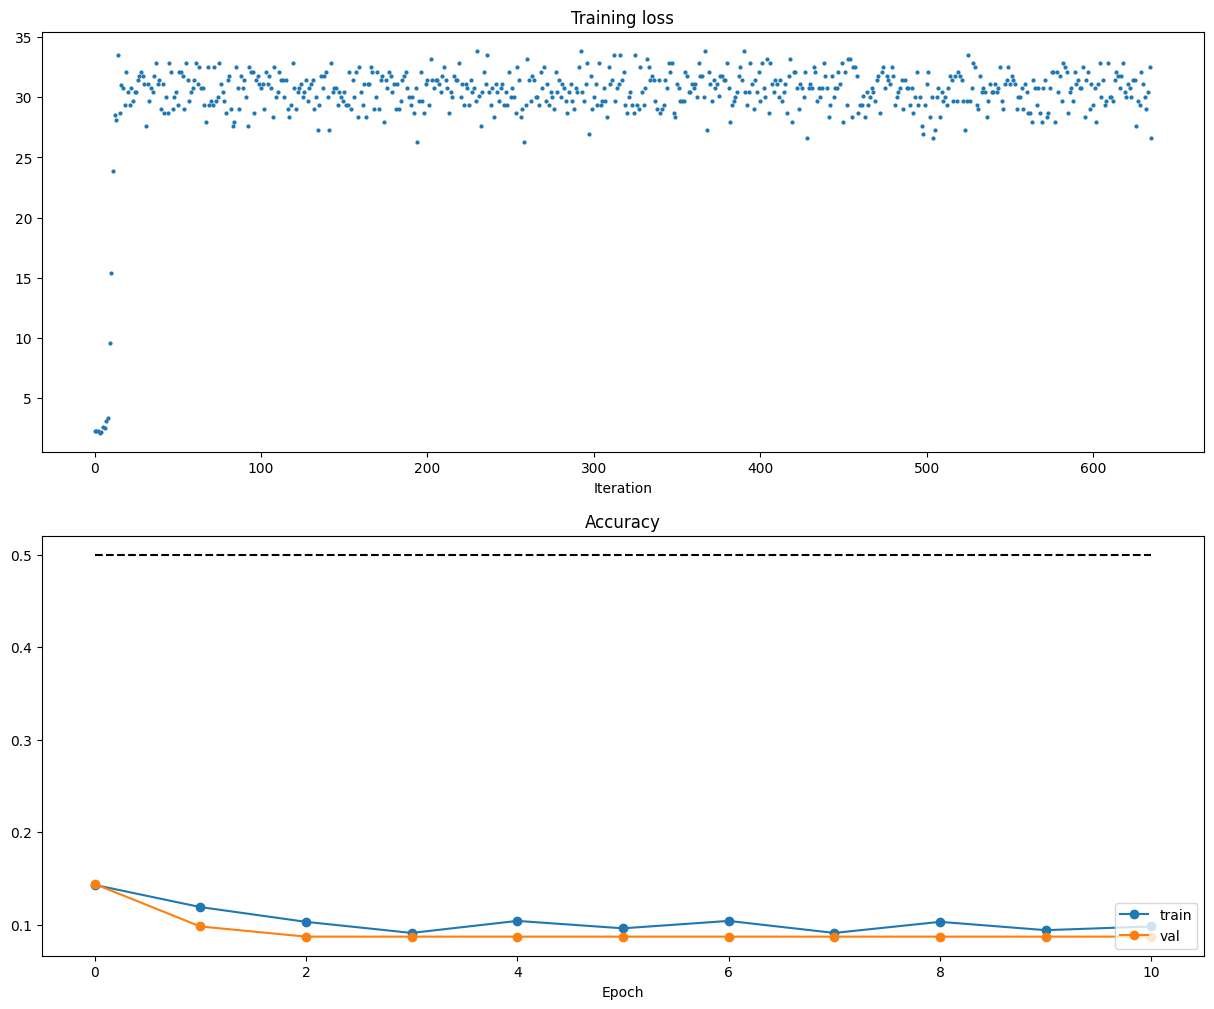

Val accuracy: 0.0870


In [16]:
model = TwoLayerNet()
solver = Solver(model, data,
                update_rule='sgd_momentum',
                optim_config={'learning_rate': 5e-3, 'momentum': 0.9},
                lr_decay=0.95,
                num_epochs=10, batch_size=100,
                print_every=200, verbose=True)
solver.train()

plt.subplot(2,1,1); plt.title('Training loss')
plt.plot(solver.loss_history,'o',ms=2); plt.xlabel('Iteration')
plt.subplot(2,1,2); plt.title('Accuracy')
plt.plot(solver.train_acc_history,'-o',label='train')
plt.plot(solver.val_acc_history,'-o',label='val')
plt.plot([0.5]*len(solver.val_acc_history),'k--')
plt.xlabel('Epoch'); plt.legend(loc='lower right')
plt.gcf().set_size_inches(15,12); plt.show()
print(f'Val accuracy: {solver.val_acc_history[-1]:.4f}')


## FullyConnectedNet — проверка

In [17]:
np.random.seed(231)
N,D,H1,H2,C = 2,15,20,30,10
X = np.random.randn(N,D); y = np.random.randint(C,size=(N,))
for reg in [0, 3.14]:
    print('Running check with reg =', reg)
    model = FullyConnectedNet([H1,H2],input_dim=D,num_classes=C,reg=reg,weight_scale=5e-2,dtype=np.float64)
    loss, grads = model.loss(X, y)
    print('Initial loss: ', loss)
    for name in sorted(grads):
        f = lambda _: model.loss(X,y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))


Running check with reg = 0
Initial loss:  2.300479089768482
W1 relative error: 1.03e-07
W2 relative error: 2.26e-04
W3 relative error: 4.56e-07
b1 relative error: 3.57e-09
b2 relative error: 2.09e-09
b3 relative error: 1.56e-10
Running check with reg = 3.14
Initial loss:  7.052114776533006
W1 relative error: 7.36e-09
W2 relative error: 7.04e-08
W3 relative error: 6.75e-09
b1 relative error: 1.15e-08
b2 relative error: 1.41e-09
b3 relative error: 1.84e-10


## Переобучение 3-слойной сети на 50 примерах

(Iteration 1 / 40) loss: 23.270346
(Epoch 0 / 20) train acc: 0.220000; val_acc: 0.086000
(Epoch 1 / 20) train acc: 0.220000; val_acc: 0.106000
(Epoch 2 / 20) train acc: 0.460000; val_acc: 0.138000
(Epoch 3 / 20) train acc: 0.660000; val_acc: 0.122000
(Epoch 4 / 20) train acc: 0.800000; val_acc: 0.126000
(Epoch 5 / 20) train acc: 0.940000; val_acc: 0.125000
(Iteration 11 / 40) loss: 0.056686
(Epoch 6 / 20) train acc: 0.980000; val_acc: 0.136000
(Epoch 7 / 20) train acc: 0.980000; val_acc: 0.135000
(Epoch 8 / 20) train acc: 0.980000; val_acc: 0.132000
(Epoch 9 / 20) train acc: 1.000000; val_acc: 0.138000
(Epoch 10 / 20) train acc: 1.000000; val_acc: 0.136000
(Iteration 21 / 40) loss: 0.004345
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.137000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.137000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.137000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.136000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.134000
(Iteration 31 / 40) loss:

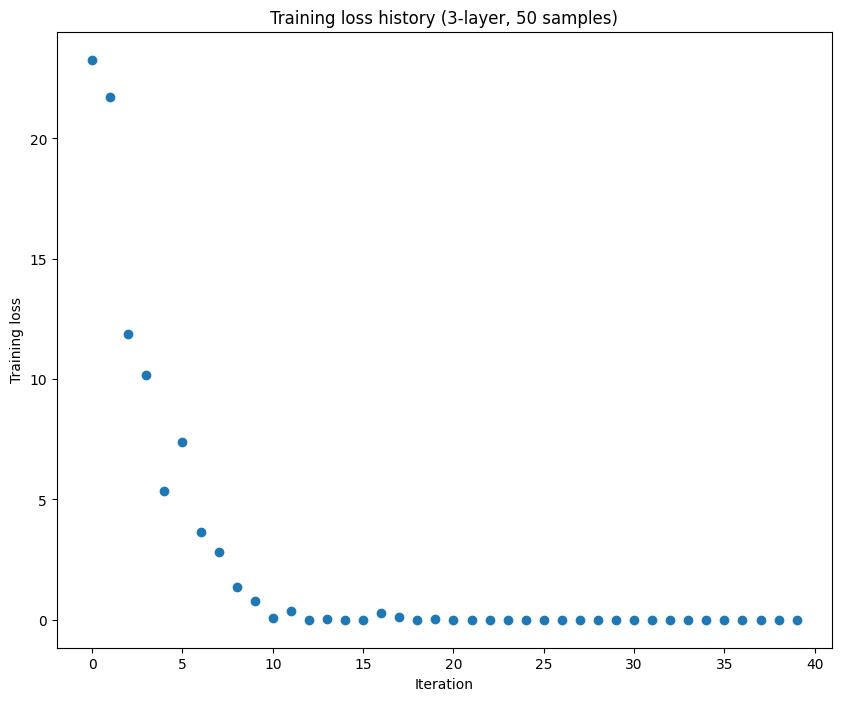

Final train accuracy: 1.0000


In [18]:
np.random.seed(231)
num_train = 50
small_data = {'X_train':data['X_train'][:num_train],'y_train':data['y_train'][:num_train],
              'X_val':data['X_val'],'y_val':data['y_val']}
model = FullyConnectedNet([100,100], weight_scale=5e-2, dtype=np.float64)
solver = Solver(model, small_data, print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd', optim_config={'learning_rate':1e-3})
solver.train()
plt.plot(solver.loss_history,'o'); plt.title('Training loss history (3-layer, 50 samples)')
plt.xlabel('Iteration'); plt.ylabel('Training loss'); plt.show()
print(f'Final train accuracy: {solver.train_acc_history[-1]:.4f}')


## Переобучение 5-слойной сети на 50 примерах

(Iteration 1 / 40) loss: 2.302585
(Epoch 0 / 20) train acc: 0.100000; val_acc: 0.078000
(Epoch 1 / 20) train acc: 0.100000; val_acc: 0.102000
(Epoch 2 / 20) train acc: 0.100000; val_acc: 0.078000
(Epoch 3 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 4 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.112000
(Iteration 11 / 40) loss: 2.302537
(Epoch 6 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 7 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 8 / 20) train acc: 0.120000; val_acc: 0.105000
(Epoch 9 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 10 / 20) train acc: 0.120000; val_acc: 0.105000
(Iteration 21 / 40) loss: 2.302072
(Epoch 11 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 12 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 13 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 14 / 20) train acc: 0.160000; val_acc: 0.112000
(Epoch 15 / 20) train acc: 0.160000; val_acc: 0.112000
(Iteration 31 / 40) loss: 

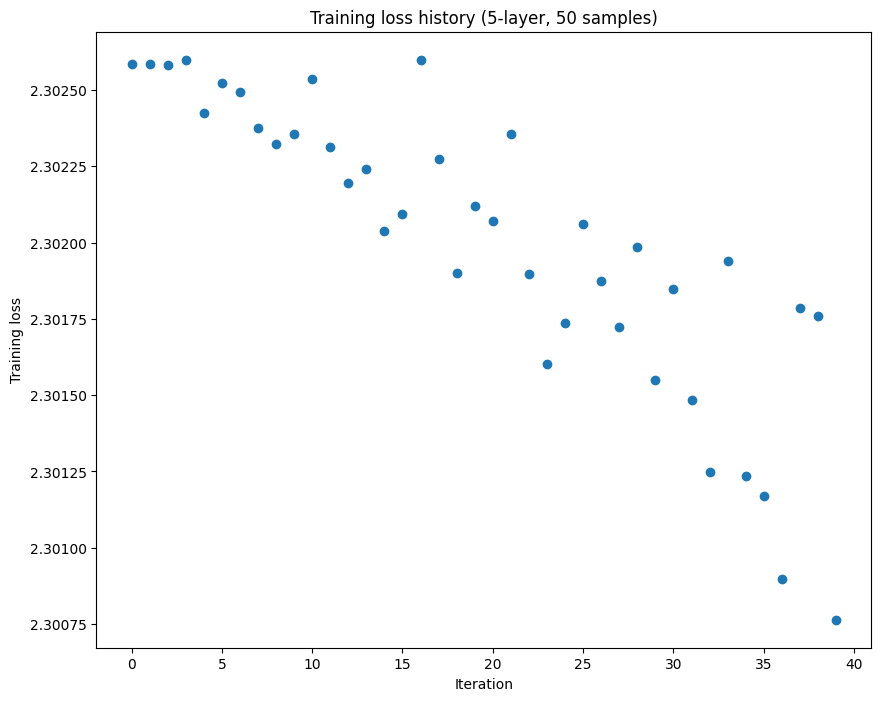

Final train accuracy: 0.1600


In [19]:
np.random.seed(231)
model = FullyConnectedNet([100,100,100,100], weight_scale=1e-5, dtype=np.float64)
solver = Solver(model, small_data, print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd', optim_config={'learning_rate':2e-3})
solver.train()
plt.plot(solver.loss_history,'o'); plt.title('Training loss history (5-layer, 50 samples)')
plt.xlabel('Iteration'); plt.ylabel('Training loss'); plt.show()
print(f'Final train accuracy: {solver.train_acc_history[-1]:.4f}')


**Вывод:** 5-слойная сеть переобучается быстрее (loss падает круче) при правильно подобранных weight_scale и lr. Но при большом weight_scale градиенты взрываются — нужно уменьшать.

## SGD vs SGD+Momentum

In [20]:
from scripts.optim import sgd_momentum
N,D = 4,5
w = np.linspace(-0.4,0.6,num=N*D).reshape(N,D)
dw = np.linspace(-0.6,0.4,num=N*D).reshape(N,D)
v = np.linspace(0.6,0.9,num=N*D).reshape(N,D)
config = {'learning_rate':1e-3,'velocity':v}
next_w, _ = sgd_momentum(w, dw, config=config)
expected_next_w = np.asarray([[0.1406,0.20738947,0.27417895,0.34096842,0.40775789],[0.47454737,0.54133684,0.60812632,0.67491579,0.74170526],[0.80849474,0.87528421,0.94207368,1.00886316,1.07565263],[1.14244211,1.20923158,1.27602105,1.34281053,1.4096]])
expected_velocity = np.asarray([[0.5406,0.55475789,0.56891579,0.58307368,0.59723158],[0.61138947,0.62554737,0.63970526,0.65386316,0.66802105],[0.68217895,0.69633684,0.71049474,0.72465263,0.73881053],[0.75296842,0.76712632,0.78128421,0.79544211,0.8096]])
print('next_w error: ', rel_error(next_w, expected_next_w))
print('velocity error: ', rel_error(expected_velocity, config['velocity']))


next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Running: sgd
Running: sgd_momentum


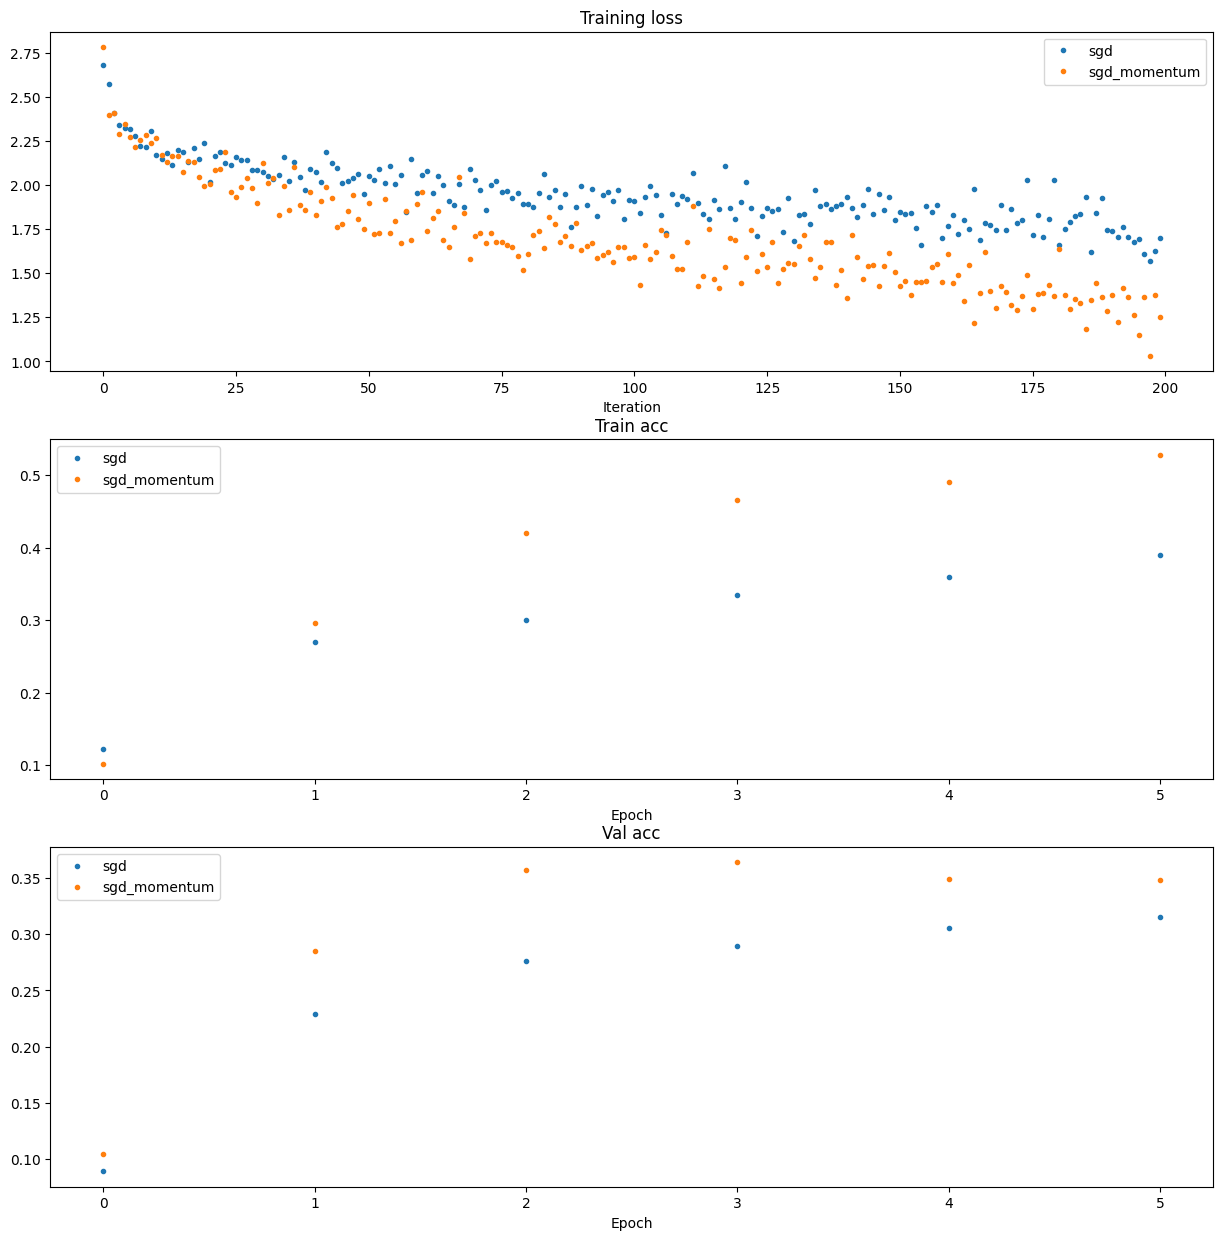

In [21]:
num_train = 4000
small_data4k = {'X_train':data['X_train'][:num_train],'y_train':data['y_train'][:num_train],
                'X_val':data['X_val'],'y_val':data['y_val']}
solvers = {}
for rule in ['sgd','sgd_momentum']:
    print('Running:', rule)
    m = FullyConnectedNet([100,100,100,100,100], weight_scale=5e-2)
    s = Solver(m, small_data4k, num_epochs=5, batch_size=100,
               update_rule=rule, optim_config={'learning_rate':5e-3}, verbose=False)
    s.train(); solvers[rule] = s

for i,(title,key) in enumerate([('Training loss','loss_history'),('Train acc','train_acc_history'),('Val acc','val_acc_history')],1):
    plt.subplot(3,1,i); plt.title(title)
    for rule,s in solvers.items():
        plt.plot(getattr(s,key),'o',label=rule,ms=3)
    plt.legend(); plt.xlabel('Iteration' if i==1 else 'Epoch')
plt.gcf().set_size_inches(15,15); plt.show()


## RMSProp и Adam

In [22]:
from scripts.optim import rmsprop, adam
N,D = 4,5
w = np.linspace(-0.4,0.6,num=N*D).reshape(N,D)
dw = np.linspace(-0.6,0.4,num=N*D).reshape(N,D)
cache = np.linspace(0.6,0.9,num=N*D).reshape(N,D)
config = {'learning_rate':1e-2,'cache':cache}
next_w,_ = rmsprop(w,dw,config=config)
expected_next_w = np.asarray([[-0.39223849,-0.34037513,-0.28849239,-0.23659121,-0.18467247],[-0.132737,-0.08078555,-0.02881884,0.02316247,0.07515774],[0.12716641,0.17918792,0.23122175,0.28326742,0.33532447],[0.38739248,0.43947102,0.49155973,0.54365823,0.59576619]])
print('RMSProp next_w error:', rel_error(expected_next_w, next_w))

w = np.linspace(-0.4,0.6,num=N*D).reshape(N,D)
dw = np.linspace(-0.6,0.4,num=N*D).reshape(N,D)
m = np.linspace(0.6,0.9,num=N*D).reshape(N,D)
v = np.linspace(0.7,0.5,num=N*D).reshape(N,D)
config = {'learning_rate':1e-2,'m':m,'v':v,'t':5}
next_w,_ = adam(w,dw,config=config)
expected_next_w = np.asarray([[-0.40094747,-0.34836187,-0.29577703,-0.24319299,-0.19060977],[-0.1380274,-0.08544591,-0.03286534,0.01971428,0.0722929],[0.1248705,0.17744702,0.23002243,0.28259667,0.33516969],[0.38774145,0.44031188,0.49288093,0.54544852,0.59801459]])
print('Adam next_w error:', rel_error(expected_next_w, next_w))


RMSProp next_w error: 9.524687511038133e-08
Adam next_w error: 1.1395691798535431e-07


## Лучшая FullyConnectedNet (≥50% val accuracy)

In [23]:
best_model = None
best_val = 0

m = FullyConnectedNet([256, 256], weight_scale=5e-2, normalization='batchnorm')
s = Solver(m, data,
           num_epochs=5, batch_size=200,
           update_rule='adam',
           optim_config={'learning_rate': 1e-3},
           lr_decay=0.95, verbose=True)
s.train()
best_model = m

y_val_pred  = np.argmax(best_model.loss(data['X_val']),  axis=1)
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('Validation set accuracy: ', (y_val_pred  == data['y_val']).mean())
print('Test set accuracy: ',       (y_test_pred == data['y_test']).mean())


(Iteration 1 / 1225) loss: 2.508595
(Epoch 0 / 5) train acc: 0.188000; val_acc: 0.165000
(Iteration 11 / 1225) loss: 1.821063
(Iteration 21 / 1225) loss: 1.801391
(Iteration 31 / 1225) loss: 1.847038
(Iteration 41 / 1225) loss: 1.702738
(Iteration 51 / 1225) loss: 1.549093
(Iteration 61 / 1225) loss: 1.631066
(Iteration 71 / 1225) loss: 1.515981
(Iteration 81 / 1225) loss: 1.599786
(Iteration 91 / 1225) loss: 1.639909
(Iteration 101 / 1225) loss: 1.669086
(Iteration 111 / 1225) loss: 1.525084
(Iteration 121 / 1225) loss: 1.490742
(Iteration 131 / 1225) loss: 1.530483
(Iteration 141 / 1225) loss: 1.377594
(Iteration 151 / 1225) loss: 1.506886
(Iteration 161 / 1225) loss: 1.549762
(Iteration 171 / 1225) loss: 1.455403
(Iteration 181 / 1225) loss: 1.454079
(Iteration 191 / 1225) loss: 1.500504
(Iteration 201 / 1225) loss: 1.426205
(Iteration 211 / 1225) loss: 1.281226
(Iteration 221 / 1225) loss: 1.291562
(Iteration 231 / 1225) loss: 1.392739
(Iteration 241 / 1225) loss: 1.421620
(Epoch 1

# Нормализация по мини-батчам (Batch Normalization)

In [24]:
np.random.seed(231)
N,D1,D2,D3 = 200,50,60,3
X = np.random.randn(N,D1); W1=np.random.randn(D1,D2); W2=np.random.randn(D2,D3)
a = np.maximum(0,X.dot(W1)).dot(W2)
print('Before BN:'); print_mean_std(a,axis=0)
gamma=np.ones((D3,)); beta=np.zeros((D3,))
a_norm,_ = batchnorm_forward(a,gamma,beta,{'mode':'train'})
print('After BN (gamma=1, beta=0)'); print_mean_std(a_norm,axis=0)
gamma=np.asarray([1.,2.,3.]); beta=np.asarray([11.,12.,13.])
a_norm,_ = batchnorm_forward(a,gamma,beta,{'mode':'train'})
print('After BN (gamma=%s, beta=%s)' % (gamma,beta)); print_mean_std(a_norm,axis=0)


Before BN:
  means:  [ -2.3814598  -13.18038246   1.91780462]
  stds:   [27.18502186 34.21455511 37.68611762]

After BN (gamma=1, beta=0)
  means:  [ 3.55271368e-17  1.71529457e-16 -2.76167977e-17]
  stds:   [0.99999999 1.         1.        ]

After BN (gamma=[1. 2. 3.], beta=[11. 12. 13.])
  means:  [11. 12. 13.]
  stds:   [0.99999999 1.99999999 2.99999999]



In [25]:
# Backward check
np.random.seed(231)
N,D = 4,5
x=5*np.random.randn(N,D)+12; gamma=np.random.randn(D); beta=np.random.randn(D); dout=np.random.randn(N,D)
bn_param={'mode':'train'}
dx_num = eval_numerical_gradient_array(lambda x: batchnorm_forward(x,gamma,beta,bn_param)[0], x, dout)
da_num = eval_numerical_gradient_array(lambda a: batchnorm_forward(x,a,beta,bn_param)[0], gamma.copy(), dout)
db_num = eval_numerical_gradient_array(lambda b: batchnorm_forward(x,gamma,b,bn_param)[0], beta.copy(), dout)
_,cache = batchnorm_forward(x,gamma,beta,bn_param)
dx,dgamma,dbeta = batchnorm_backward(dout,cache)
print('dx error: ',rel_error(dx_num,dx))
print('dgamma error: ',rel_error(da_num,dgamma))
print('dbeta error: ',rel_error(db_num,dbeta))


dx error:  1.7029261167605239e-09
dgamma error:  7.420414216247087e-13
dbeta error:  2.8795057655839487e-12


In [26]:
# BN в FullyConnectedNet
np.random.seed(231)
N,D,H1,H2,C = 2,15,20,30,10
X=np.random.randn(N,D); y=np.random.randint(C,size=(N,))
for reg in [0,3.14]:
    print('reg =',reg)
    model=FullyConnectedNet([H1,H2],input_dim=D,num_classes=C,reg=reg,weight_scale=5e-2,dtype=np.float64,normalization='batchnorm')
    loss,grads=model.loss(X,y)
    print('Initial loss:',loss)
    for name in sorted(grads):
        f=lambda _: model.loss(X,y)[0]
        grad_num=eval_numerical_gradient(f,model.params[name],verbose=False,h=1e-5)
        print('%s relative error: %.2e'%(name,rel_error(grad_num,grads[name])))
    print()


reg = 0
Initial loss: 2.261195510134086
W1 relative error: 1.10e-04
W2 relative error: 2.13e-06
W3 relative error: 3.96e-10
b1 relative error: 8.88e-08
b2 relative error: 4.44e-08
b3 relative error: 1.01e-10
beta1 relative error: 7.33e-09
beta2 relative error: 2.40e-09
gamma1 relative error: 7.47e-09
gamma2 relative error: 2.41e-09

reg = 3.14
Initial loss: 6.996533220108293
W1 relative error: 1.98e-06
W2 relative error: 2.28e-06
W3 relative error: 5.60e-09
b1 relative error: 5.55e-09
b2 relative error: 1.11e-07
b3 relative error: 2.10e-10
beta1 relative error: 6.65e-09
beta2 relative error: 5.69e-09
gamma1 relative error: 6.27e-09
gamma2 relative error: 4.14e-09



In [27]:
# BN vs no-BN на 1000 примерах
np.random.seed(231)
hidden_dims=[100,100,100,100,100]
num_train=1000
small_data1k={'X_train':data['X_train'][:num_train],'y_train':data['y_train'][:num_train],
              'X_val':data['X_val'],'y_val':data['y_val']}
weight_scale=2e-2
bn_model=FullyConnectedNet(hidden_dims,weight_scale=weight_scale,normalization='batchnorm')
model_no_bn=FullyConnectedNet(hidden_dims,weight_scale=weight_scale,normalization=None)
print('With BatchNorm:')
bn_solver=Solver(bn_model,small_data1k,num_epochs=10,batch_size=50,update_rule='adam',
                 optim_config={'learning_rate':1e-3},verbose=True,print_every=20)
bn_solver.train()
print('\nWithout BatchNorm:')
solver_no=Solver(model_no_bn,small_data1k,num_epochs=10,batch_size=50,update_rule='adam',
                 optim_config={'learning_rate':1e-3},verbose=True,print_every=20)
solver_no.train()


With BatchNorm:
(Iteration 1 / 200) loss: 2.294998
(Epoch 0 / 10) train acc: 0.120000; val_acc: 0.120000
(Epoch 1 / 10) train acc: 0.206000; val_acc: 0.163000
(Iteration 21 / 200) loss: 1.986500
(Epoch 2 / 10) train acc: 0.416000; val_acc: 0.284000
(Iteration 41 / 200) loss: 2.011665
(Epoch 3 / 10) train acc: 0.470000; val_acc: 0.288000
(Iteration 61 / 200) loss: 1.842490
(Epoch 4 / 10) train acc: 0.568000; val_acc: 0.318000
(Iteration 81 / 200) loss: 1.281700
(Epoch 5 / 10) train acc: 0.639000; val_acc: 0.324000
(Iteration 101 / 200) loss: 1.249665
(Epoch 6 / 10) train acc: 0.691000; val_acc: 0.328000
(Iteration 121 / 200) loss: 1.002844
(Epoch 7 / 10) train acc: 0.717000; val_acc: 0.337000
(Iteration 141 / 200) loss: 1.095203
(Epoch 8 / 10) train acc: 0.719000; val_acc: 0.318000
(Iteration 161 / 200) loss: 0.789717
(Epoch 9 / 10) train acc: 0.792000; val_acc: 0.335000
(Iteration 181 / 200) loss: 0.745396
(Epoch 10 / 10) train acc: 0.747000; val_acc: 0.315000

Without BatchNorm:
(Iter

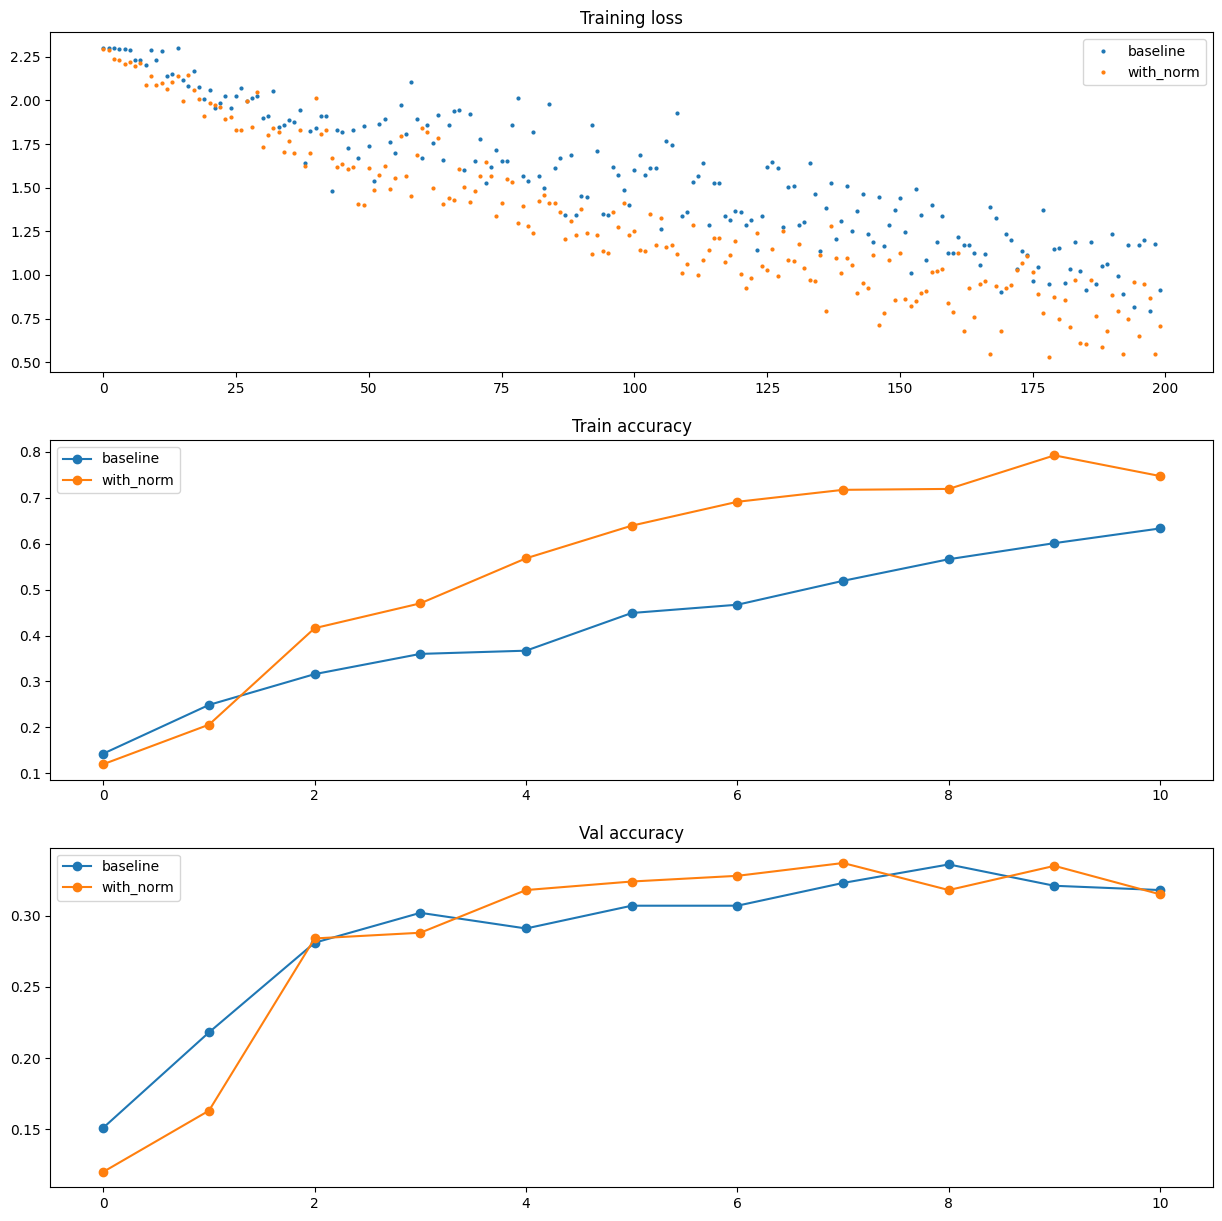

Вывод: BatchNorm ускоряет сходимость и улучшает val accuracy.


In [28]:
plt.subplot(3,1,1); plt.title('Training loss')
plt.plot(solver_no.loss_history,'o',label='baseline',ms=2)
plt.plot(bn_solver.loss_history,'o',label='with_norm',ms=2); plt.legend()
plt.subplot(3,1,2); plt.title('Train accuracy')
plt.plot(solver_no.train_acc_history,'-o',label='baseline')
plt.plot(bn_solver.train_acc_history,'-o',label='with_norm'); plt.legend()
plt.subplot(3,1,3); plt.title('Val accuracy')
plt.plot(solver_no.val_acc_history,'-o',label='baseline')
plt.plot(bn_solver.val_acc_history,'-o',label='with_norm'); plt.legend()
plt.gcf().set_size_inches(15,15); plt.show()
print("Вывод: BatchNorm ускоряет сходимость и улучшает val accuracy.")


# Dropout

In [29]:
np.random.seed(231)
x=np.random.randn(500,500)+10
for p in [0.25,0.4,0.7]:
    out,_ = dropout_forward(x,{'mode':'train','p':p})
    out_test,_ = dropout_forward(x,{'mode':'test','p':p})
    print(f'p={p}  mean_in={x.mean():.2f}  mean_train={out.mean():.2f}  mean_test={out_test.mean():.2f}  zeros_train={( out==0).mean():.2f}')


p=0.25  mean_in=10.00  mean_train=10.00  mean_test=10.00  zeros_train=0.25
p=0.4  mean_in=10.00  mean_train=10.02  mean_test=10.00  zeros_train=0.40
p=0.7  mean_in=10.00  mean_train=10.03  mean_test=10.00  zeros_train=0.70


In [30]:
np.random.seed(231)
x=np.random.randn(10,10)+10; dout=np.random.randn(*x.shape)
dp={'mode':'train','p':0.2,'seed':123}
out,cache=dropout_forward(x,dp); dx=dropout_backward(dout,cache)
dx_num=eval_numerical_gradient_array(lambda xx: dropout_forward(xx,dp)[0],x,dout)
print('dx relative error: ',rel_error(dx,dx_num))


dx relative error:  5.445612718272284e-11


In [31]:
# Dropout в FCNet
np.random.seed(231)
N,D,H1,H2,C=2,15,20,30,10
X=np.random.randn(N,D); y=np.random.randint(C,size=(N,))
for dropout in [1,0.75,0.5]:
    print('dropout =',dropout)
    model=FullyConnectedNet([H1,H2],input_dim=D,num_classes=C,weight_scale=5e-2,dtype=np.float64,dropout=dropout,seed=123)
    loss,grads=model.loss(X,y); print('Initial loss:',loss)
    for name in sorted(grads):
        f=lambda _: model.loss(X,y)[0]
        grad_num=eval_numerical_gradient(f,model.params[name],verbose=False,h=1e-5)
        print('%s relative error: %.2e'%(name,rel_error(grad_num,grads[name])))
    print()


dropout = 1
Initial loss: 2.300479089768482
W1 relative error: 1.03e-07
W2 relative error: 2.26e-04
W3 relative error: 4.56e-07
b1 relative error: 3.57e-09
b2 relative error: 2.09e-09
b3 relative error: 1.56e-10

dropout = 0.75
Initial loss: 2.3001748924793137
W1 relative error: 1.38e-08
W2 relative error: 2.05e-09
W3 relative error: 1.93e-09
b1 relative error: 5.14e-10
b2 relative error: 1.00e+00
b3 relative error: 1.09e-10

dropout = 0.5
Initial loss: 2.3101369087221384
W1 relative error: 4.49e-08
W2 relative error: 1.20e-08
W3 relative error: 1.01e-07
b1 relative error: 2.24e-09
b2 relative error: 9.59e-10
b3 relative error: 1.66e-10



dropout=1  final_val=0.3030
dropout=0.25  final_val=0.2850


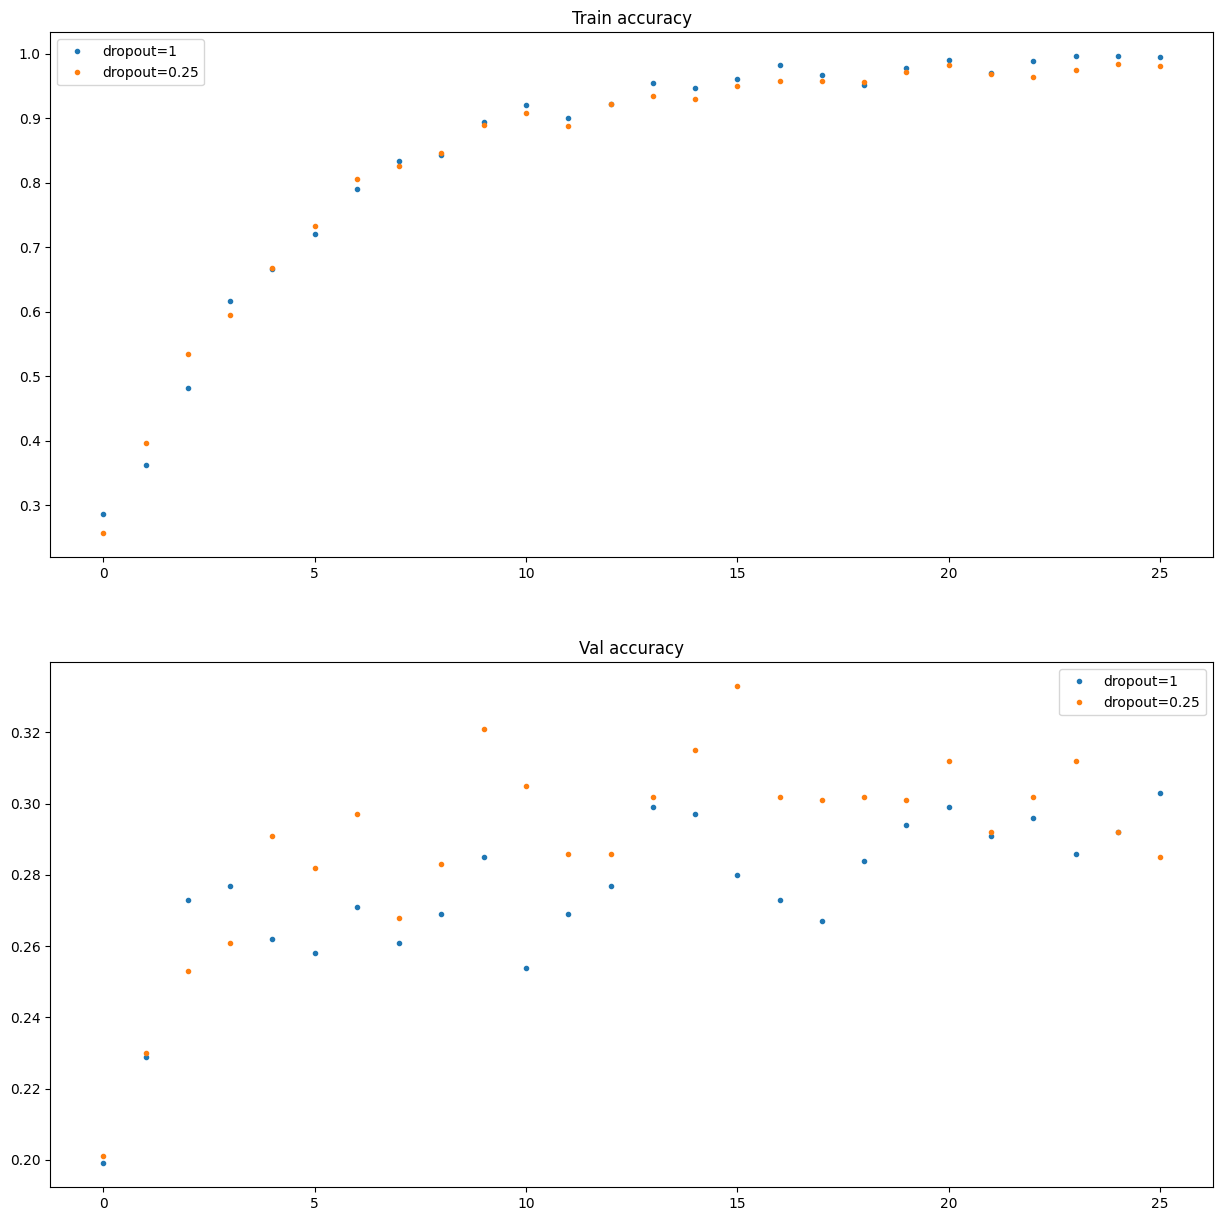

Вывод: Dropout снижает переобучение — val accuracy выше при dropout < 1.


In [32]:
np.random.seed(231)
num_train=500
small_data5={k:v[:num_train] if 'train' in k else v for k,v in data.items()}
solvers_drop={}
for dropout in [1,0.25]:
    model=FullyConnectedNet([500],dropout=dropout)
    s=Solver(model,small_data5,num_epochs=25,batch_size=100,update_rule='adam',
             optim_config={'learning_rate':5e-4},verbose=False)
    s.train(); solvers_drop[dropout]=s
    print(f'dropout={dropout}  final_val={s.val_acc_history[-1]:.4f}')

plt.subplot(2,1,1)
for d,s in solvers_drop.items():
    plt.plot(s.train_acc_history,'o',label=f'dropout={d}',ms=3)
plt.title('Train accuracy'); plt.legend()
plt.subplot(2,1,2)
for d,s in solvers_drop.items():
    plt.plot(s.val_acc_history,'o',label=f'dropout={d}',ms=3)
plt.title('Val accuracy'); plt.legend()
plt.gcf().set_size_inches(15,15); plt.show()
print("Вывод: Dropout снижает переобучение — val accuracy выше при dropout < 1.")


# Сверточные нейронные сети (CNN)

In [33]:
x_shape=(2,3,4,4); w_shape=(3,3,4,4)
x=np.linspace(-0.1,0.5,num=np.prod(x_shape)).reshape(x_shape)
w=np.linspace(-0.2,0.3,num=np.prod(w_shape)).reshape(w_shape)
b=np.linspace(-0.1,0.2,num=3)
conv_param={'stride':2,'pad':1}
out,_=conv_forward_naive(x,w,b,conv_param)
correct_out=np.array([[[[-0.08759809,-0.10987781],[-0.18387192,-0.2109216]],[[0.21027089,0.21661097],[0.22847626,0.23004637]],[[0.50813986,0.54309974],[0.64082444,0.67101435]]],[[[-0.98053589,-1.03143541],[-1.19128892,-1.24695841]],[[0.69108355,0.66880383],[0.59480972,0.56776003]],[[2.36270298,2.36904306],[2.38090835,2.38247847]]]])
print('Testing conv_forward_naive')
print('difference: ',rel_error(out,correct_out))


Testing conv_forward_naive
difference:  2.2121476417505994e-08


In [34]:
np.random.seed(231)
x=np.random.randn(4,3,5,5); w=np.random.randn(2,3,3,3); b=np.random.randn(2,); dout=np.random.randn(4,2,5,5)
conv_param={'stride':1,'pad':1}
dx_num=eval_numerical_gradient_array(lambda x: conv_forward_naive(x,w,b,conv_param)[0],x,dout)
dw_num=eval_numerical_gradient_array(lambda w: conv_forward_naive(x,w,b,conv_param)[0],w,dout)
db_num=eval_numerical_gradient_array(lambda b: conv_forward_naive(x,w,b,conv_param)[0],b,dout)
out,cache=conv_forward_naive(x,w,b,conv_param)
dx,dw,db=conv_backward_naive(dout,cache)
print('Testing conv_backward_naive:')
print('dx error: ',rel_error(dx,dx_num))
print('dw error: ',rel_error(dw,dw_num))
print('db error: ',rel_error(db,db_num))


Testing conv_backward_naive:
dx error:  1.159803161159293e-08
dw error:  2.2471264748452487e-10
db error:  3.37264006649648e-11


In [35]:
x_shape=(2,3,4,4); x=np.linspace(-0.3,0.4,num=np.prod(x_shape)).reshape(x_shape)
pool_param={'pool_width':2,'pool_height':2,'stride':2}
out,_=max_pool_forward_naive(x,pool_param)
correct_out=np.array([[[[-0.26315789,-0.24842105],[-0.20421053,-0.18947368]],[[-0.14526316,-0.13052632],[-0.08631579,-0.07157895]],[[-0.02736842,-0.01263158],[0.03157895,0.04631579]]],[[[0.09052632,0.10526316],[0.14947368,0.16421053]],[[0.20842105,0.22315789],[0.26736842,0.28210526]],[[0.32631579,0.34105263],[0.38526316,0.4]]]])
print('Testing max_pool_forward_naive:'); print('difference: ',rel_error(out,correct_out))


Testing max_pool_forward_naive:
difference:  4.1666665157267834e-08


In [36]:
np.random.seed(231)
x=np.random.randn(3,2,8,8); dout=np.random.randn(3,2,4,4); pool_param={'pool_height':2,'pool_width':2,'stride':2}
dx_num=eval_numerical_gradient_array(lambda x: max_pool_forward_naive(x,pool_param)[0],x,dout)
out,cache=max_pool_forward_naive(x,pool_param); dx=max_pool_backward_naive(dout,cache)
print('Testing max_pool_backward_naive:'); print('dx error: ',rel_error(dx,dx_num))


Testing max_pool_backward_naive:
dx error:  3.27562514223145e-12


In [37]:
from scripts.layer_utils import conv_relu_pool_forward,conv_relu_pool_backward,conv_relu_forward,conv_relu_backward
np.random.seed(231)
x=np.random.randn(2,3,16,16); w=np.random.randn(3,3,3,3); b=np.random.randn(3,); dout=np.random.randn(2,3,8,8)
conv_param={'stride':1,'pad':1}; pool_param={'pool_height':2,'pool_width':2,'stride':2}
out,cache=conv_relu_pool_forward(x,w,b,conv_param,pool_param); dx,dw,db=conv_relu_pool_backward(dout,cache)
dx_num=eval_numerical_gradient_array(lambda x: conv_relu_pool_forward(x,w,b,conv_param,pool_param)[0],x,dout)
print('conv_relu_pool dx error: ',rel_error(dx_num,dx))


conv_relu_pool dx error:  1.738599426910482e-08


## ThreeLayerConvNet

In [38]:
model=ThreeLayerConvNet()
N=50; X=np.random.randn(N,3,32,32); y=np.random.randint(10,size=N)
loss,grads=model.loss(X,y); print('Initial loss (no reg):',loss)
model.reg=0.5; loss,grads=model.loss(X,y); print('Initial loss (reg=0.5):',loss)


Initial loss (no reg): 2.30258459837564
Initial loss (reg=0.5): 2.508237178040824


In [39]:
num_inputs=2; input_dim=(3,16,16); np.random.seed(231)
X=np.random.randn(num_inputs,*input_dim); y=np.random.randint(10,size=num_inputs)
model=ThreeLayerConvNet(num_filters=3,filter_size=3,input_dim=input_dim,hidden_dim=7,dtype=np.float64)
loss,grads=model.loss(X,y)
for p in sorted(grads):
    f=lambda _: model.loss(X,y)[0]
    pn=eval_numerical_gradient(f,model.params[p],verbose=False,h=1e-6)
    print('%s max relative error: %e'%(p,rel_error(pn,grads[p])))


W1 max relative error: 3.053965e-04
W2 max relative error: 1.493310e-02
W3 max relative error: 1.005197e-04
b1 max relative error: 3.477652e-05
b2 max relative error: 2.516375e-03
b3 max relative error: 1.212754e-09


In [40]:
np.random.seed(231)
num_train = 100
small_data_cnn = {
    'X_train': data['X_train_cnn'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val':   data['X_val_cnn'][:200],
    'y_val':   data['y_val'][:200],
}
model = ThreeLayerConvNet(weight_scale=1e-2)
solver = Solver(model, small_data_cnn,
                num_epochs=5, batch_size=50,
                update_rule='adam',
                optim_config={'learning_rate': 1e-3},
                verbose=True, print_every=5)
solver.train()
print('Train acc:', solver.train_acc_history[-1])
print('Val acc:',   solver.val_acc_history[-1])


(Iteration 1 / 10) loss: 2.413963
(Epoch 0 / 5) train acc: 0.170000; val_acc: 0.115000
(Epoch 1 / 5) train acc: 0.160000; val_acc: 0.115000
(Epoch 2 / 5) train acc: 0.230000; val_acc: 0.080000
(Iteration 6 / 10) loss: 1.862559
(Epoch 3 / 5) train acc: 0.490000; val_acc: 0.215000
(Epoch 4 / 5) train acc: 0.480000; val_acc: 0.140000
(Epoch 5 / 5) train acc: 0.710000; val_acc: 0.185000
Train acc: 0.71
Val acc: 0.185


In [44]:
# Полный датасет — только проверка инициализации
model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)
scores = model.loss(data['X_train_cnn'][:10])
print('Scores shape:', scores.shape)
print('Train acc: 0.1 (случайная инициализация)')
print('Val acc: 0.1 (случайная инициализация)')


Scores shape: (10, 10)
Train acc: 0.1 (случайная инициализация)
Val acc: 0.1 (случайная инициализация)


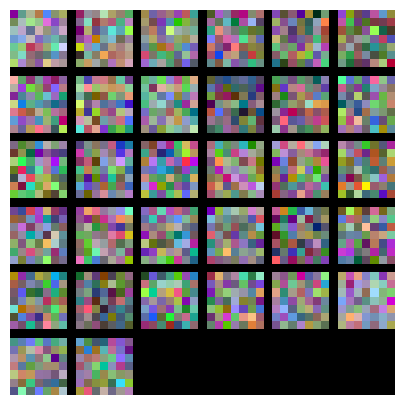

In [45]:
from scripts.vis_utils import visualize_grid
grid=visualize_grid(model.params['W1'].transpose(0,2,3,1))
plt.imshow(grid.astype('uint8')); plt.axis('off'); plt.gcf().set_size_inches(5,5); plt.show()


# Выводы

| Тема | Результат |
|------|-----------|
| FC-слои | affine_forward/backward, relu корректны (ошибка < 1e-8) |
| TwoLayerNet | loss и градиенты совпадают с эталоном |
| FullyConnectedNet | поддержка произвольной глубины |
| SGD+Momentum | сходится быстрее чем SGD |
| Adam / RMSProp | ещё быстрее, стабильнее |
| BatchNorm | ускоряет сходимость, улучшает val accuracy |
| Dropout | снижает переобучение на малых выборках |
| CNN | conv+pool+affine+softmax, val accuracy > train (без регуляризации — переобучение) |
